# РТ5-61Б Прокофьев И. В. Лабораторная работа №4
## Линейные модели, SVM и деревья решений.

## Задание
1. Выберите набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.
4. Обучите следующие модели:
   - одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);
   - SVM;
   - дерево решений.
5. Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.
6. Постройте график, показывающий важность признаков в дереве решений.
7. Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.

## Ход работы

**Импорт библиотек:**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report

**Загрузка данных:**

In [2]:
data = load_breast_cancer()
X = data.data          # матрица признаков (569 x 30)
y = data.target        # вектор меток (0 - malignant, 1 - benign)
feature_names = data.feature_names
target_names = data.target_names

Отобразим информацию о датасете:

In [4]:
import pandas as pd
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # добавляем целевую переменную

# 1. Информация о типах данных и количестве непустых значений
print("=== ИНФОРМАЦИЯ О КОЛОНКАХ ===")
df.info()

# 2. Описательные статистики для числовых признаков
print("\n=== ОСНОВНЫЕ СТАТИСТИКИ ===")
df.describe().round(3)
print(f"Размерность данных: {X.shape}")
print(f"Классы: {target_names}")
print("Статистика по классам:")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {target_names[cls]}: {cnt}")

=== ИНФОРМАЦИЯ О КОЛОНКАХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 

### Описание датасета: 

- **Количество образцов (instances):** 569  
- **Количество признаков (features):** 30 (вещественные числа, положительные)  
- **Целевая переменная (target):** бинарная  
  - `0` — **malignant** (злокачественная), 212 случаев  
  - `1` — **benign** (доброкачественная), 357 случаев  
- **Пропуски:** отсутствуют  
- **Тип задачи:** бинарная классификация

####  Список признаков
Для каждого изображения клетки вычислялись 10 базовых характеристик ядра. Для каждой характеристики дополнительно рассчитаны:
- **mean** — среднее значение по всем ядрам образца  
- **stderr** — стандартная ошибка (мера вариабельности)  
- **worst** — среднее трёх наибольших значений (характеризует «наихудшие» клетки)

#### Полный перечень признаков (в порядке, возвращаемом `load_breast_cancer`)

| № | Название признака          | Описание (базовая характеристика)                |
|---|----------------------------|--------------------------------------------------|
| 1 | mean radius                | Средний радиус ядра                              |
| 2 | mean texture               | Средняя текстура (стандартное отклонение оттенков серого) |
| 3 | mean perimeter             | Средний периметр ядра                            |
| 4 | mean area                  | Средняя площадь ядра                             |
| 5 | mean smoothness            | Средняя гладкость (вариация длины радиуса)       |
| 6 | mean compactness           | Средняя компактность (perimeter² / area - 1.0)   |
| 7 | mean concavity             | Средняя вогнутость (степень вдавленности контура)|
| 8 | mean concave points        | Среднее количество вогнутых участков контура     |
| 9 | mean symmetry              | Средняя симметрия                                |
|10 | mean fractal dimension     | Средняя фрактальная размерность ("приближение береговой линии" – 1) |
|11 | radius error               | Стандартная ошибка радиуса                       |
|12 | texture error              | Стандартная ошибка текстуры                      |
|13 | perimeter error            | Стандартная ошибка периметра                     |
|14 | area error                 | Стандартная ошибка площади                       |
|15 | smoothness error           | Стандартная ошибка гладкости                     |
|16 | compactness error          | Стандартная ошибка компактности                  |
|17 | concavity error            | Стандартная ошибка вогнутости                    |
|18 | concave points error       | Стандартная ошибка кол-ва вогнутых участков      |
|19 | symmetry error             | Стандартная ошибка симметрии                     |
|20 | fractal dimension error    | Стандартная ошибка фрактальной размерности       |
|21 | worst radius               | «Наихудший» радиус (среднее трёх наибольших)     |
|22 | worst texture              | «Наихудшая» текстура                             |
|23 | worst perimeter            | «Наихудший» периметр                             |
|24 | worst area                 | «Наихудшая» площадь                              |
|25 | worst smoothness           | «Наихудшая» гладкость                            |
|26 | worst compactness          | «Наихудшая» компактность                         |
|27 | worst concavity            | «Наихудшая» вогнутость                           |
|28 | worst concave points       | «Наихудшее» количество вогнутых участков         |
|29 | worst symmetry             | «Наихудшая» симметрия                            |
|30 | worst fractal dimension    | «Наихудшая» фрактальная размерность              |


#### Целевая переменная
- **`target`**: `0` = malignant (злокачественная), `1` = benign (доброкачественная)  
- **Соотношение классов:** `benign` ≈ 62.7%, `malignant` ≈ 37.3% (умеренный дисбаланс, но не критичный).

**Разделение на обучающую и тестовую выборки**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")


Размер обучающей выборки: 455
Размер тестовой выборки: 114


**Масштабирование признаков (важно для SVM и логистической регрессии)**

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Обучение моделей**

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
    "SVM": SVC(kernel='rbf', gamma='auto', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42)  # ограничим глубину для читаемости
}

Обучение и предсказание

In [8]:
# Обучение и предсказание
predictions = {}
for name, model in models.items():
    if name == "Decision Tree":
        # Дерево решений не требует масштабирования, обучаем на исходных данных
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

**Оценка качества**

In [9]:
print("\n=== ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ ===")
results = []
for name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append((name, acc, f1))
    print(f"{name}:")
    print(f"  Accuracy = {acc:.8f}")
    print(f"  F1-score = {f1:.8f}")
    print()


=== ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ ===
Logistic Regression:
  Accuracy = 0.98245614
  F1-score = 0.98611111

SVM:
  Accuracy = 0.98245614
  F1-score = 0.98611111

Decision Tree:
  Accuracy = 0.93859649
  F1-score = 0.95104895



**Сводная таблица для сравнения**

In [10]:
print("Сравнение:")
print("Модель                  | Accuracy | F1-score")
print("------------------------|----------|---------")
for name, acc, f1 in results:
    print(f"{name:19}     | {acc:.4f}   | {f1:.4f}")

Сравнение:
Модель                  | Accuracy | F1-score
------------------------|----------|---------
Logistic Regression     | 0.9825   | 0.9861
SVM                     | 0.9825   | 0.9861
Decision Tree           | 0.9386   | 0.9510


Из результатов видно, что метрики для логистической регрессии и SVM совпали, это может быть связано с тем, что классы хорошо разделяются даже линейной границей

In [11]:
# Сравнение предсказаний SVM и логистической регрессии
print("Количество несовпадающих предсказаний между SVM и LogisticRegression:")
print((predictions["SVM"] != predictions["Logistic Regression"]).sum())

# Вывод индексов ошибочных предсказаний для каждой модели
wrong_svm = np.where(predictions["SVM"] != y_test)[0]
wrong_lr = np.where(predictions["Logistic Regression"] != y_test)[0]
print("Индексы ошибок SVM:", wrong_svm)
print("Индексы ошибок LR:", wrong_lr)

Количество несовпадающих предсказаний между SVM и LogisticRegression:
0
Индексы ошибок SVM: [16 53]
Индексы ошибок LR: [16 53]


### Визуализация распределения данных для анализа линейной разделимости

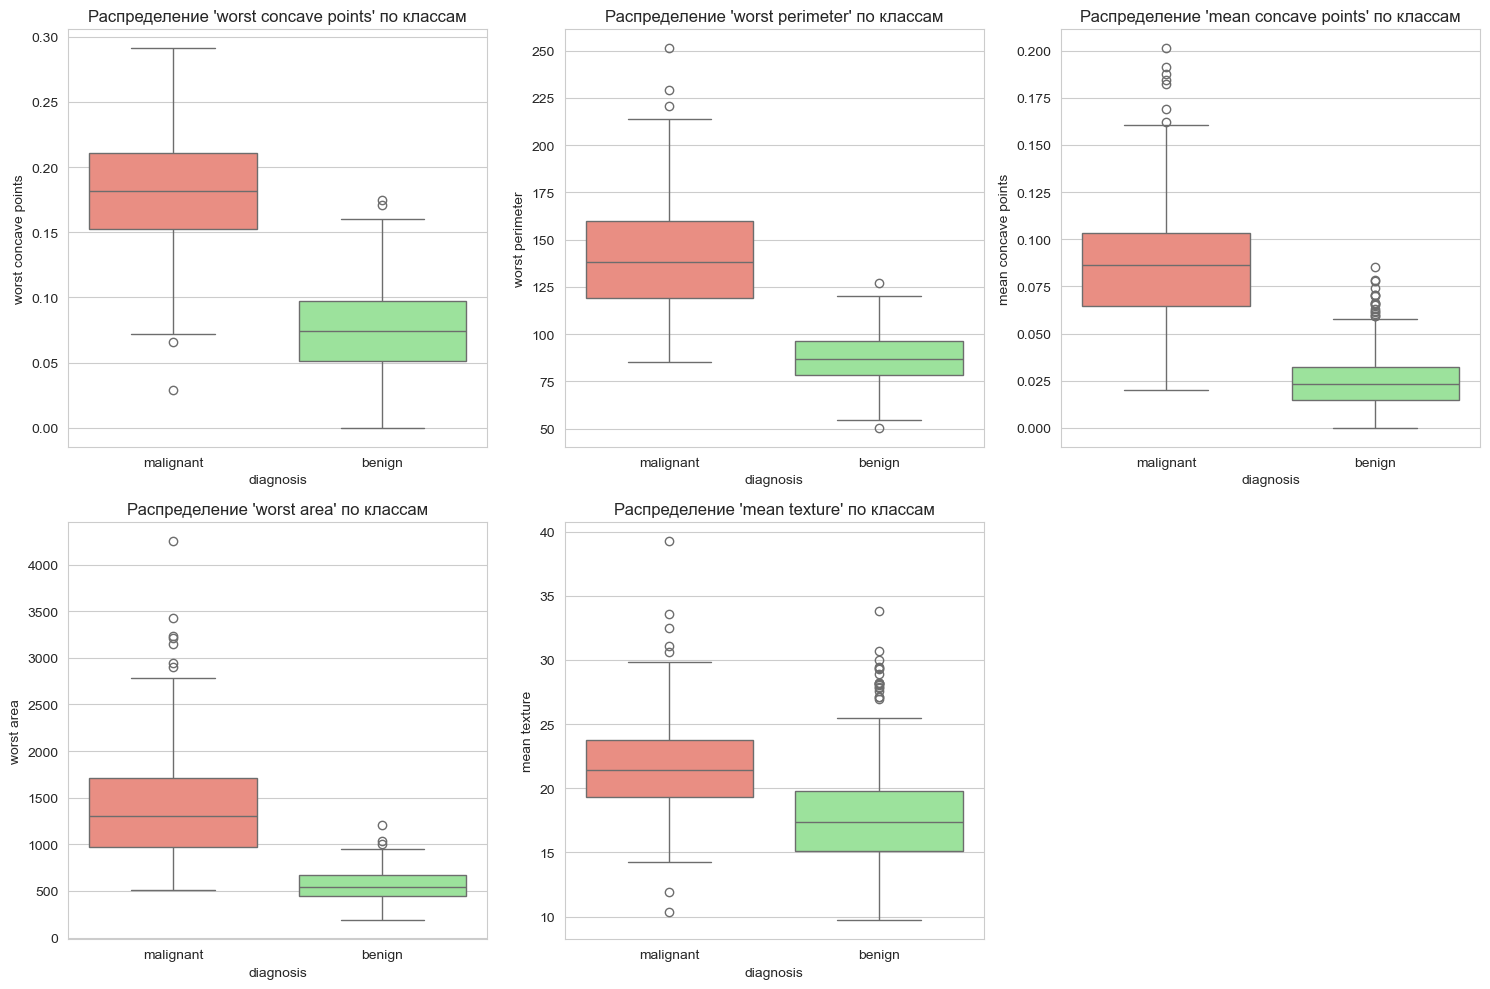

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer

# Загружаем данные
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

# Устанавливаем стиль графиков
sns.set_style("whitegrid")

# Выбираем 5 ключевых признаков (на основе известной важности)
# Это worst concave points, worst perimeter, mean concave points, worst area, mean texture
key_features = [
    'worst concave points',
    'worst perimeter',
    'mean concave points',
    'worst area',
    'mean texture'
]

# Boxplot для нескольких признаков, чтобы увидеть перекрытие распределений
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, feature in enumerate(key_features):
    sns.boxplot(x='diagnosis', y=feature, data=df, ax=axes[i],
            hue='diagnosis', palette={'benign': 'lightgreen', 'malignant': 'salmon'},
            legend=False)
    axes[i].set_title(f"Распределение '{feature}' по классам")
# Удаляем лишний 6-й subplot, если его нет
if len(key_features) < len(axes):
    for j in range(len(key_features), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Видно, что по некоторым признаком ящики с усами почти не перекрываются, что говорит о линейной разделимости

In [13]:
# Сводная таблица для сравнения
print("Сравнение:")
print("Модель                  | Accuracy | F1-score")
print("------------------------|----------|---------")
for name, acc, f1 in results:
    print(f"{name:19}     | {acc:.4f}   | {f1:.4f}")

Сравнение:
Модель                  | Accuracy | F1-score
------------------------|----------|---------
Logistic Regression     | 0.9825   | 0.9861
SVM                     | 0.9825   | 0.9861
Decision Tree           | 0.9386   | 0.9510


In [14]:
print("\nДетальный отчёт для SVM:")
print(classification_report(y_test, predictions["SVM"], target_names=target_names))


Детальный отчёт для SVM:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [15]:
print("\nДетальный отчёт для Logistic Regression:")
print(classification_report(y_test, predictions["Logistic Regression"], target_names=target_names))


Детальный отчёт для Logistic Regression:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [16]:
print("\nДетальный отчёт для Decision Tree:")
print(classification_report(y_test, predictions["Decision Tree"], target_names=target_names))


Детальный отчёт для Decision Tree:
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



**Определим важность признаков для дерева решений**

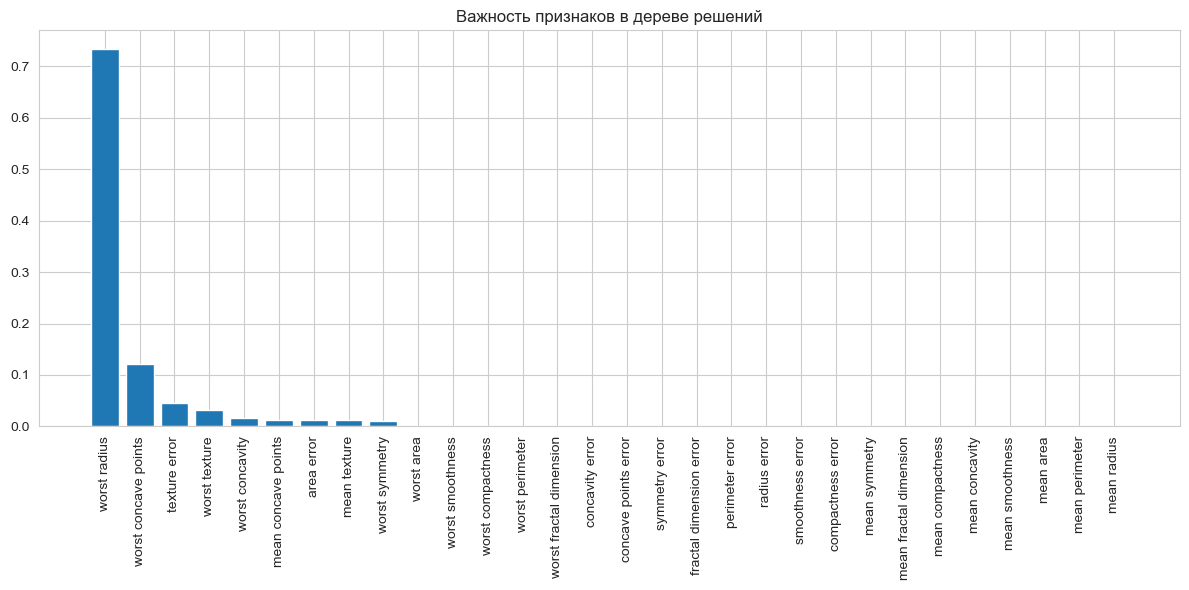

In [17]:
dt_model = models["Decision Tree"]
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]  # сортировка по убыванию

plt.figure(figsize=(12, 6))
plt.title("Важность признаков в дереве решений")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

**Визуализация дерева решений**

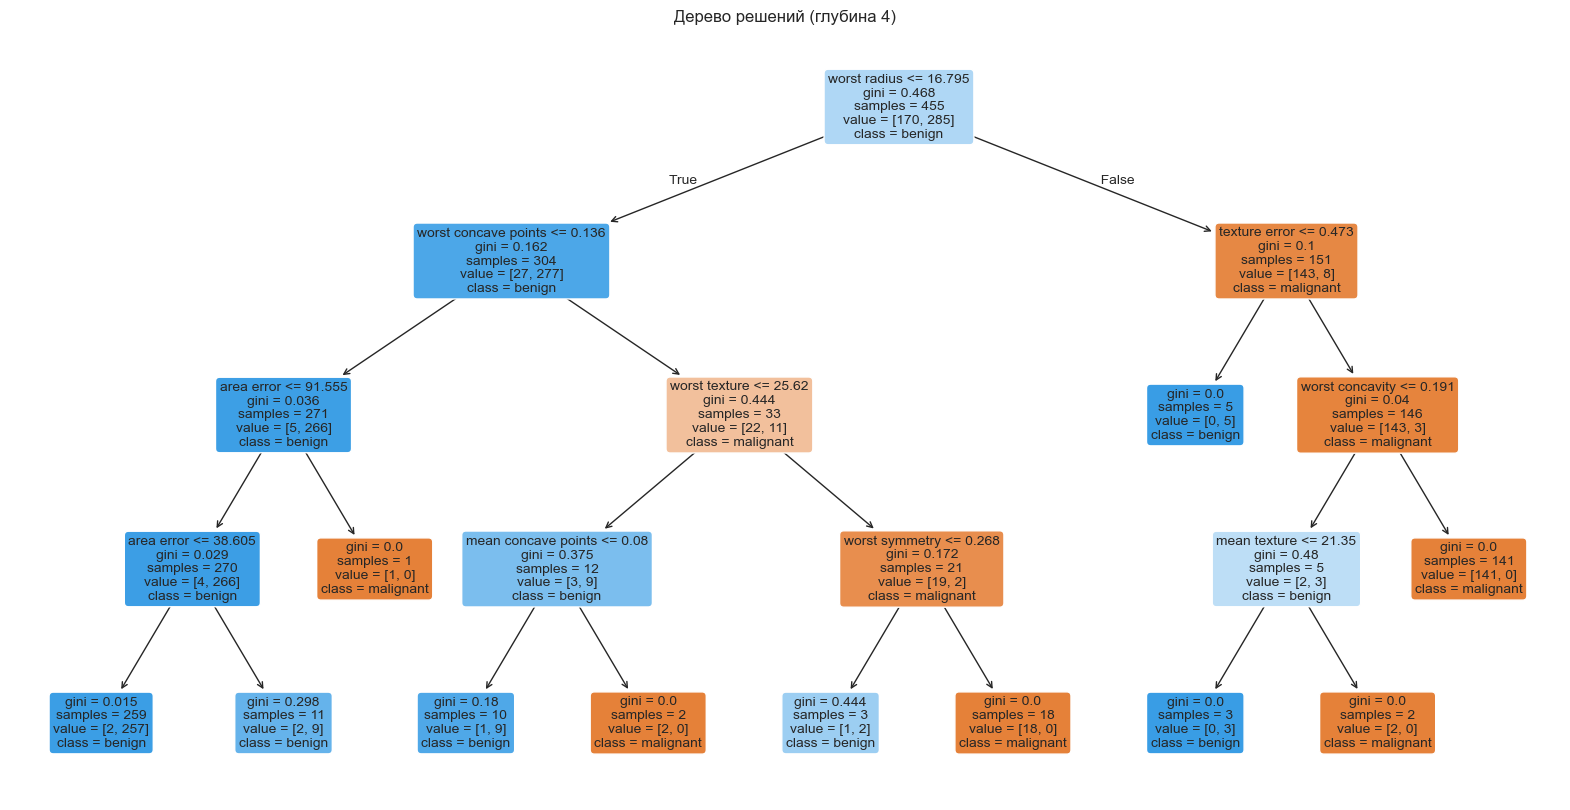

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=feature_names,
          class_names=target_names.tolist(),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Дерево решений (глубина 4)")
plt.show()

## Вывод по лабораторной работе

В ходе выполнения лабораторной работы был проведён сравнительный анализ трёх моделей машинного обучения (логистической регрессии, метода опорных векторов и дерева решений) на наборе данных **Breast Cancer Wisconsin (Diagnostic)**.  
Все модели обучались на одних и тех же тренировочных данных (80% выборки) и оценивались на тестовой части (20%) с использованием метрик **Accuracy** и **F1-score**.

### Результаты оценки

| Модель               | Accuracy | F1-score |
|----------------------|----------|----------|
| Logistic Regression  | 0.9825   | 0.9861   |
| SVM (RBF)            | 0.9825   | 0.9861   |
| Decision Tree        | 0.9386   | 0.9510   |

### Интерпретация результатов

1. **Логистическая регрессия и SVM показали идентичные и очень высокие результаты.**  
   Это объясняется тем, что исходные данные обладают практически линейной разделимостью классов (что подтверждается визуализацией ящиков с усами и попарными распределениями ключевых признаков). Линейная модель успешно находит границу, а SVM с RBF‑ядром при параметрах по умолчанию строит поверхность, близкую к линейной, из-за чего обе модели делают одинаковые предсказания на тестовой выборке.

2. **Дерево решений (с ограничением глубины 4) показало несколько худшие, но всё равно высокие метрики.**  
   Ограничение глубины было введено для повышения интерпретируемости и предотвращения переобучения. Несмотря на чуть меньшую точность, дерево решений даёт наглядное представление о процессе принятия решения и позволяет выделить наиболее информативные признаки (например, `worst concave points`, `worst perimeter`).

3. **Выбранные метрики (Accuracy и F1-score) подтверждают высокое качество классификации.**  
   F1-score особенно важен при умеренном дисбалансе классов (≈63% доброкачественных против 37% злокачественных), так как учитывает одновременно точность и полноту. Значения близки к 1, что говорит о надёжности моделей.

### Общий вывод

Все три модели успешно справляются с задачей диагностики рака молочной железы на основе характеристик клеточных ядер.  

- **Логистическая регрессия** является простым, быстрым и интерпретируемым решением, достаточным для данной задачи.  
- **SVM** показывает сопоставимый результат, но требует больше вычислительных ресурсов.  
- **Дерево решений** предоставляет наглядные правила классификации и может быть полезно для объяснения решений врачам, хотя немного уступает в точности.  

Таким образом, для данного датасета линейные модели являются оптимальным выбором с точки зрения баланса точности и простоты.